# IRIS Multiclass Classification Problem

In [1]:
from IPython.display import Image
Image(url='https://frenzy86.s3.eu-west-2.amazonaws.com/fav/iris.png',width=900,height=300)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

dataset_path='https://frenzy86.s3.eu-west-2.amazonaws.com/fav/iris.data'

df = pd.read_csv(dataset_path, header=None)
df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df['class'].value_counts(normalize=True)

,proportion
class,
Iris-setosa,0.333333
Iris-versicolor,0.333333
Iris-virginica,0.333333


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [6]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
## only notebook local
!pip install jupyter-summarytools -q

from summarytools import dfSummary
dfSummary(df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.9 MB/s eta 0:00:00


No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,sepal length[float64],Mean (sd) : 5.8 (0.8)min < med < max:4.3 < 5.8 < 7.9IQR (CV) : 1.3 (7.1),35 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAArRJREFUeJzt3U2K4kAYgOGvxlaiQoIIuvMCA7Nw6SHmsHOEWXgCb+BOkBAx08GYZFYNPY3tT1Uy1lf9Pvv8LF7kS1JdbZqmEcB33559A8A9Xp59A10xxgxFZOBwilPTNK9t3Q/cBBmqMWY4nU5/xnE8sT3H4XBIjTG/iNUPQYYqIoM4jier1eo1SZLi0YOzLIvW6/Vkv98PRIRQPRBqqCIikiRJMZvN/lgePrS9ruPYwchxQdChPoPr2MHIcRmhts967GDk+ByhdsRh7LAeOULGe1SoQKhQgVChQqczKl+H0JbOQuXrENrU5S8qX4fQms5fTz3r6xDCwsMUVCBUqECoUIFQoQKhQgVChQqEChUIFSoQKlRg4bRnqqrqi0hsjLE9RZALeQjVI3me98uy/LFYLHq9Xu/h9REi4S7kIVSPnE6nlyiKRsvlspjP5+mjx4e8kIdQPTQej1nI8wGhfsJhVozruu53cEtfGqFe4DIrlmUZVVX1vSiK3yJi+6uIDwj1ApdZcbvdTjabzeh8Pve6ur+viFCvsJkV0zQNckZ8Nl74QwWvf1F5oMEbb0PlgQbveRsqDzR4z9tQ3/BAAxEepqAEoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChws0vUw7bm7MwBK25GqrL9uYsDEGbbv2iWm9vzsIQtOmuRSk225uzMARt4mEKKhAqVCBUqOD9wmk8xnGTNacN1hz/U+PVaxNqQFw3WXPZYM31PzXeujahBsTl78xa2GDN+lXmPdcm1ADZbrJWVVUs9mNDXNd1P0mS1HKDt6uvMwkVIuI+NnT9JZJQISLue7N2/SWSUPEP27Gh6y+RvEeFCoQKFQgVKhAqVCBUqECoUIFQoQKhQoW7XvhnWRY9euLj8RiJiOR5Hu12u9H/PF7rtbXet+vx9/T1F2ecvMUVF0/ZAAAAAElFTkSuQmCC"">",0(0.0%)
2,sepal width[float64],Mean (sd) : 3.1 (0.4)min < med < max:2.0 < 3.0 < 4.4IQR (CV) : 0.5 (7.0),23 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAsNJREFUeJzt3b2O2kAUQOE7sCDzI1sIBTqalJFSUPIQedg8QgqegCJNKjokZIFwFmFsUqSKwgKeGe/ONefrR7g4whiPr83lchEgdK2PPgDgES8ffQChMsb0RKRrufx0uVxefR7PsyPUK4wxvfF4/C2O45HN+v1+nxpjvhOrP4R6XTeO49FisXhNkuRYZeFut4uWy+Vou912RYRQPSHUG5IkOU4mk98WS3veD+bJcTEFFQgVKhAqVCBUqECoUIFQoQKhQgVChQqEChW4M1WDoig6IhIbY2yWs6HlCkL1LMuyTp7nX2ezWbvdblfaJyDChpa3EKpnp9PpJYqi/nw+P06n07TKWja0vI1QazIYDNjQ4hEXU1CBUKECoUIFQoUKhAoVCBUqECpUIFSo0Ng//B0HSMRlWXZ8Hg/cNDJU1wESeZ5HRVF8OR6PP0TE5u4SPGtkqOIwQEJEZL1ej1arVf98PrfrODhUF3SoDqfvuCzLTpIkqc399jRNud8emGBDdTl9c+punmBDFYfTN6fu5gk5VBGxm//Eqbt5+B8VKhAqVCBUqECoUIFQoQKhQgVChQqEChUIFSoQKlQgVKhAqFCBUKECoUIFQoUKhAoVgt84jWocHxMPdiw7oTaI62PiIY9lJ9RmsX7OLPSx7IQaGMc3qjg9Ji4Bj2Un1IC4vlGlyY+JE2pAXN6oItLsx8QJNUC2b1Rp8mPitYbKRD34UluoTNSDT3V+ozJRD97U/hvVZiSPSLN/b6E67vVDhbvfqK4zSi3WAf+5GSozShGKe9+ozChFEB66mGJG6XNw3Gcg8veap7Rce3OLIXemICLu+wyKouhkWfZ5OBz+arVaedX197YYEipExNs+g0/z+fxn1fWPbDEkVPzDdZ+B7Xq5s8XwoVB3u11U9VMPh0MkIpJlWbTZbPrvuV7rZ2s9btf1j/T1B0Evn/P+FKZjAAAAAElFTkSuQmCC"">",0(0.0%)
3,petal length[float64],Mean (sd) : 3.8 (1.8)min < med < max:1.0 < 4.3 < 6.9IQR (CV) : 3.5 (2.1),43 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAqdJREFUeJzt3U2K4kAYxvGnxg+iQkQE3XmBgVm49BBz2DnCLDyBN3AniETMtKjR2Q0M09NqVWLXW/x/664Y6Ick75uqirvdbgJi9+WzTwB4RPveHzjnepK6nsc/3W63N8+xwB8fBtU51xuPx9/zPB/5HHy/3++ccz8IK0Ldu6J28zwfLRaLt+FweHzmwEVRZMvlcrTdbruSCCqC3L31S9JwODxOJpNfHsfveYwB/kExBRMIKkwgqDCBoMIEggoTCCpMIKgwgaDCBIIKEwgqTCCoMOGhd/14ncBplVKiUysJakRCp1VK6U6tJKhx8Z5WKaU9tZKgRihgWqWU6NRKiimYwBW1AQEFUX69Xjt1n08KCGrNQgqi8/mcVVX19Xg8/pTke+tPEkGtn3dBtF6vR6vVqn+5XFpNnZxVBLUhPgXRbrdLshCqA8UUTCCoMIGgwgSCChMIKkwgqDCBoMIEggoTCCpMIKgwgaDCBN71J6aqqo6k3DnnMzza9VYENSFlWXbO5/O32WzWarVaTy9liXm9FUFNyOl0amdZ1p/P58fpdLp7Zmzs660IaoIGg0FyW9lTTMEEggoTCCpMIKgwgaDChEar/sDmsxRxAxqv1VhQQ5vPUtwNaLxWY0ENaT5L8Teg8VqNN/wDms9SxA3oFMX8qMabKUiK/1GNoEJS/I9qBBV/ifVRjT4qTCCoMIFb/3+wGW9cCOo72Iw3PgT1fWzGGxmC+gE2440HxRRM4IqK2jS5VJugohZNL9UmqKhF00u1CSpq1dRS7WSDGvg5cZr2kUkyqKGfE6dpH58kg6rAz4nTtI9PqkGV5P85cZr28aHhDxMeuqIWRZE9e+DD4ZBJUlmW2Waz6T87viiKrKqqtvwayPn1em37nLcUdu6fNdbybz/yf/oNy3KMDhJgavYAAAAASUVORK5CYII="">",0(0.0%)
4,petal width[float64],Mean (sd) : 1.2 (0.8)min < med < max:0.1 < 1.3 < 2.5IQ

In [9]:
import seaborn as sns
sns.set(color_codes=True)

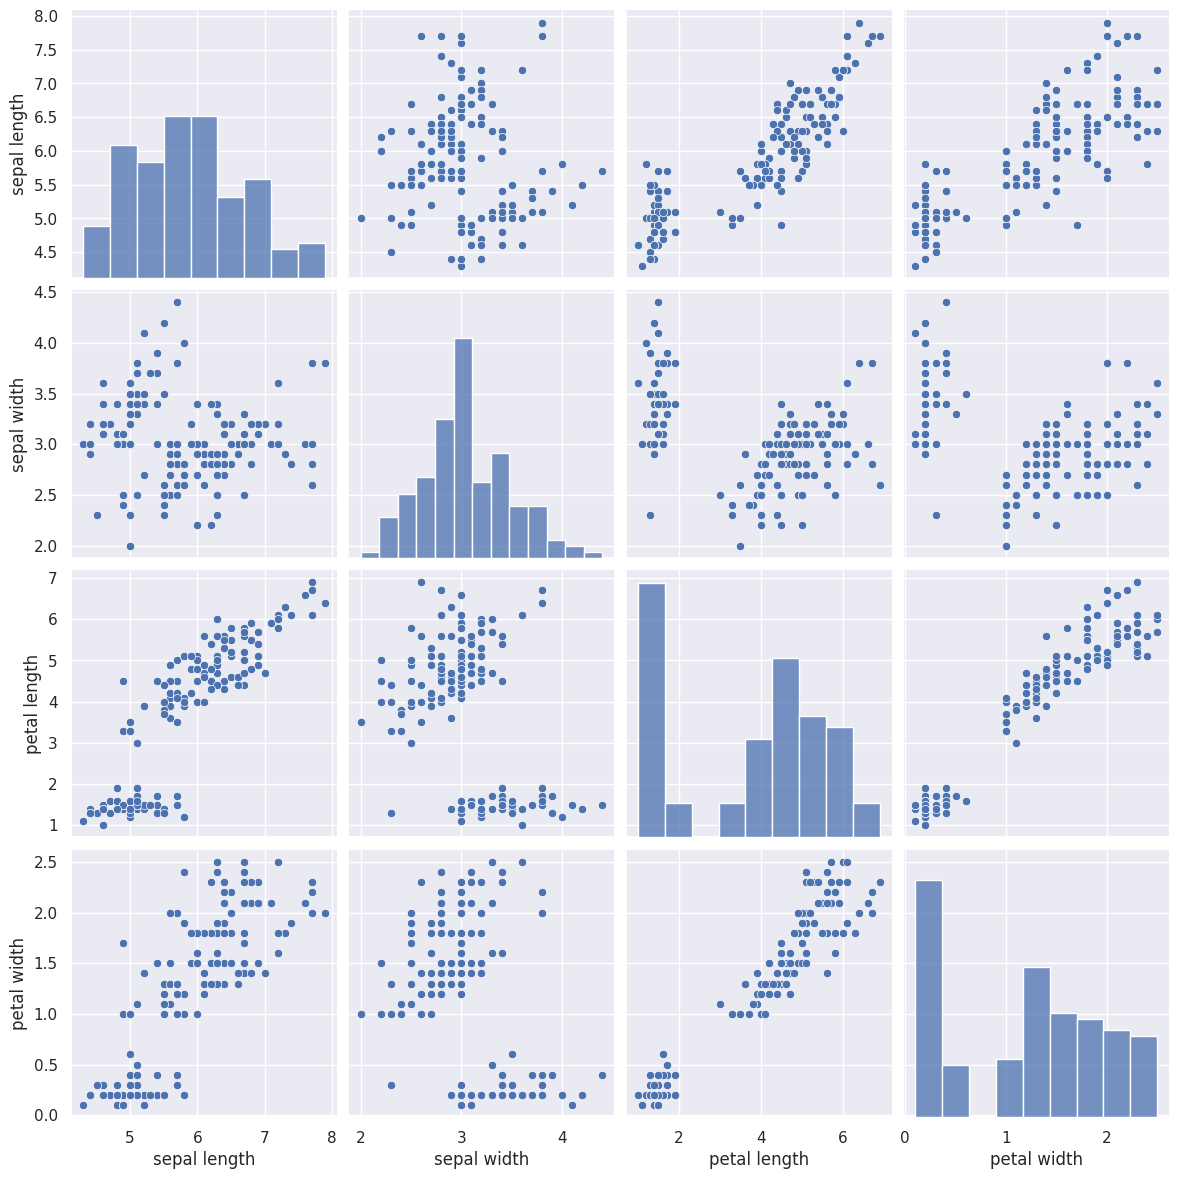

In [10]:
sns.pairplot(df, height=3, aspect=1);

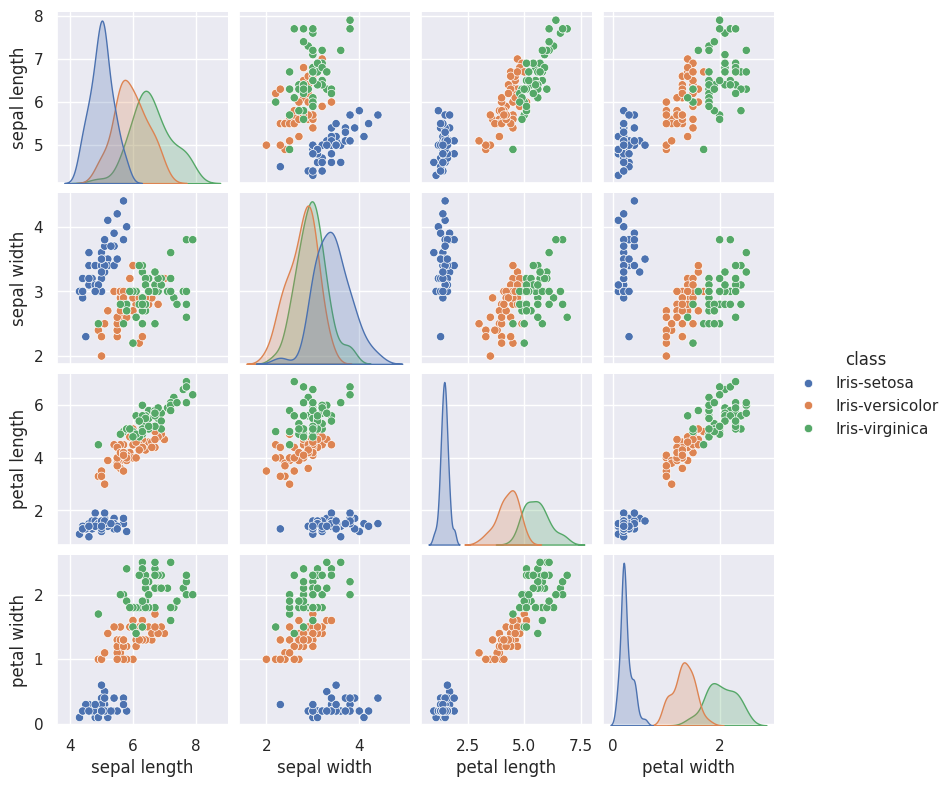

In [11]:
sns.pairplot(df, hue='class', height=2, aspect=1);

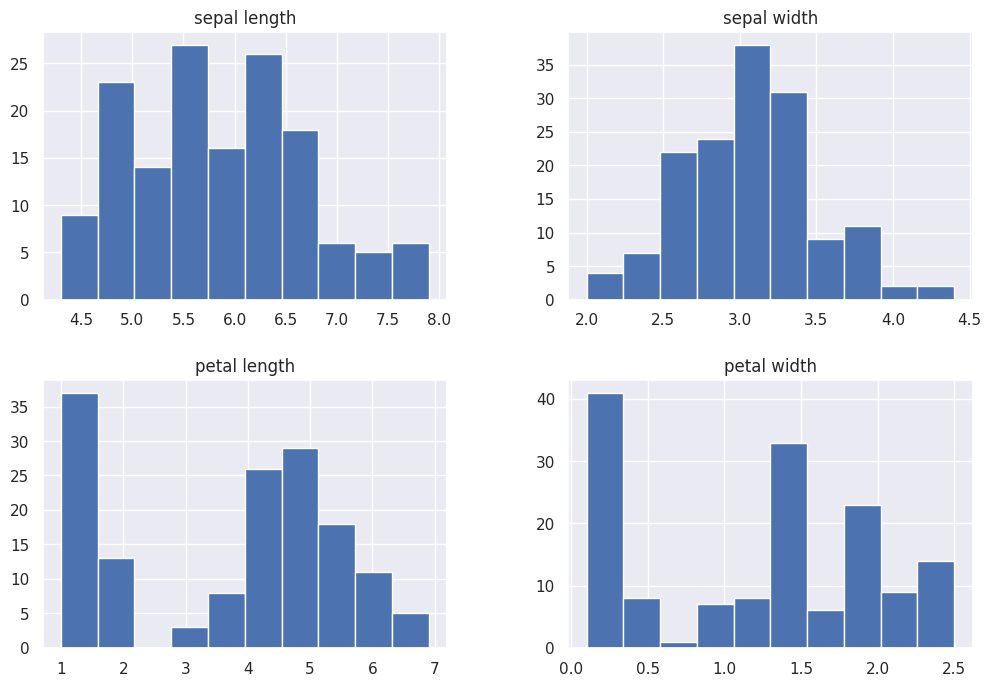

In [12]:
df.hist(figsize=(12,8));

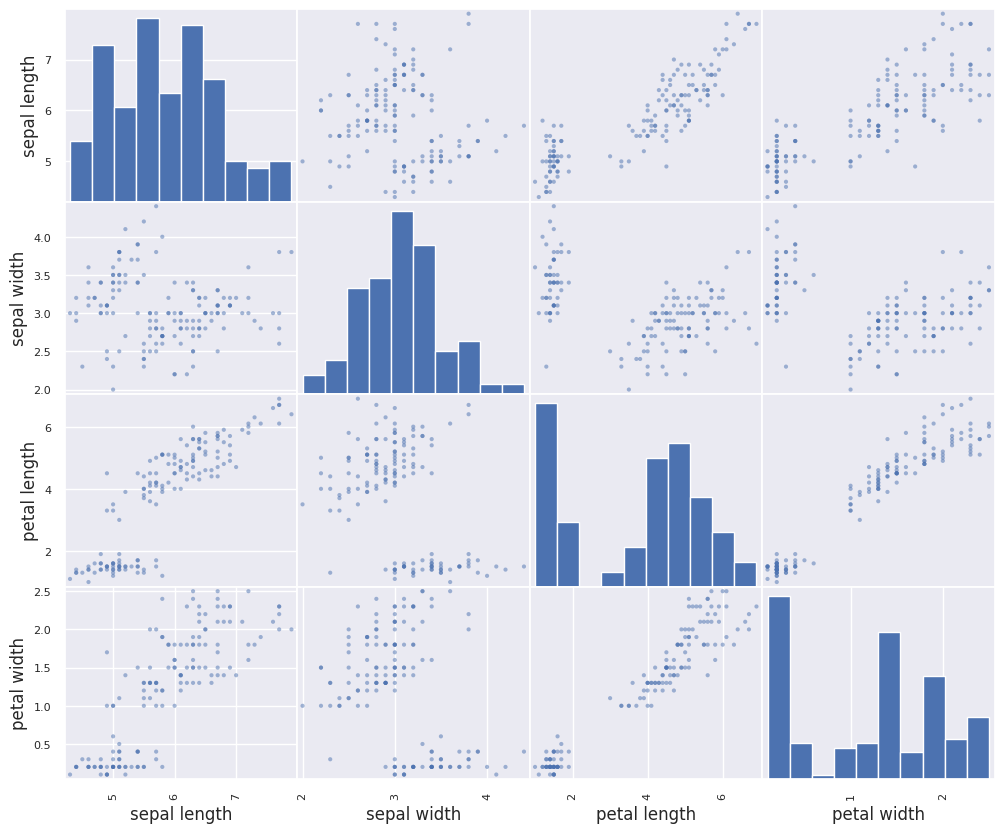

In [13]:
pd.plotting.scatter_matrix(df, figsize=(12,10));

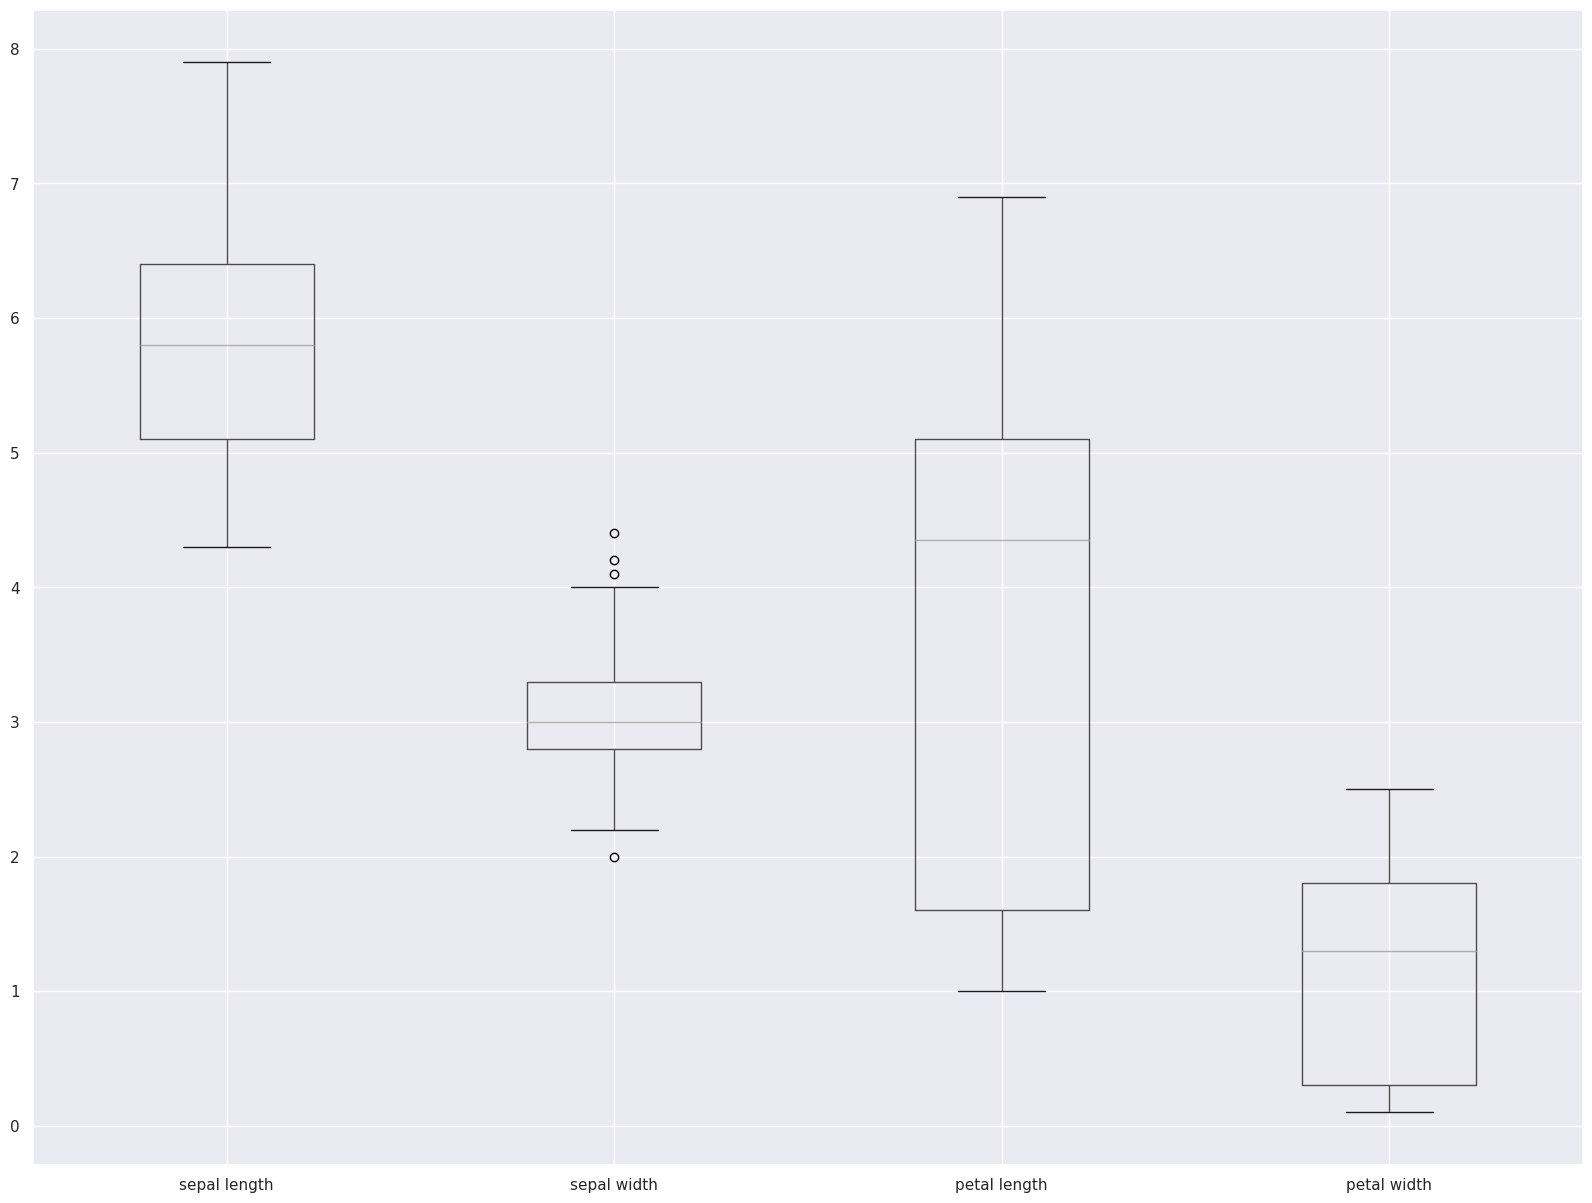

In [14]:
df.boxplot(figsize=(20,15));

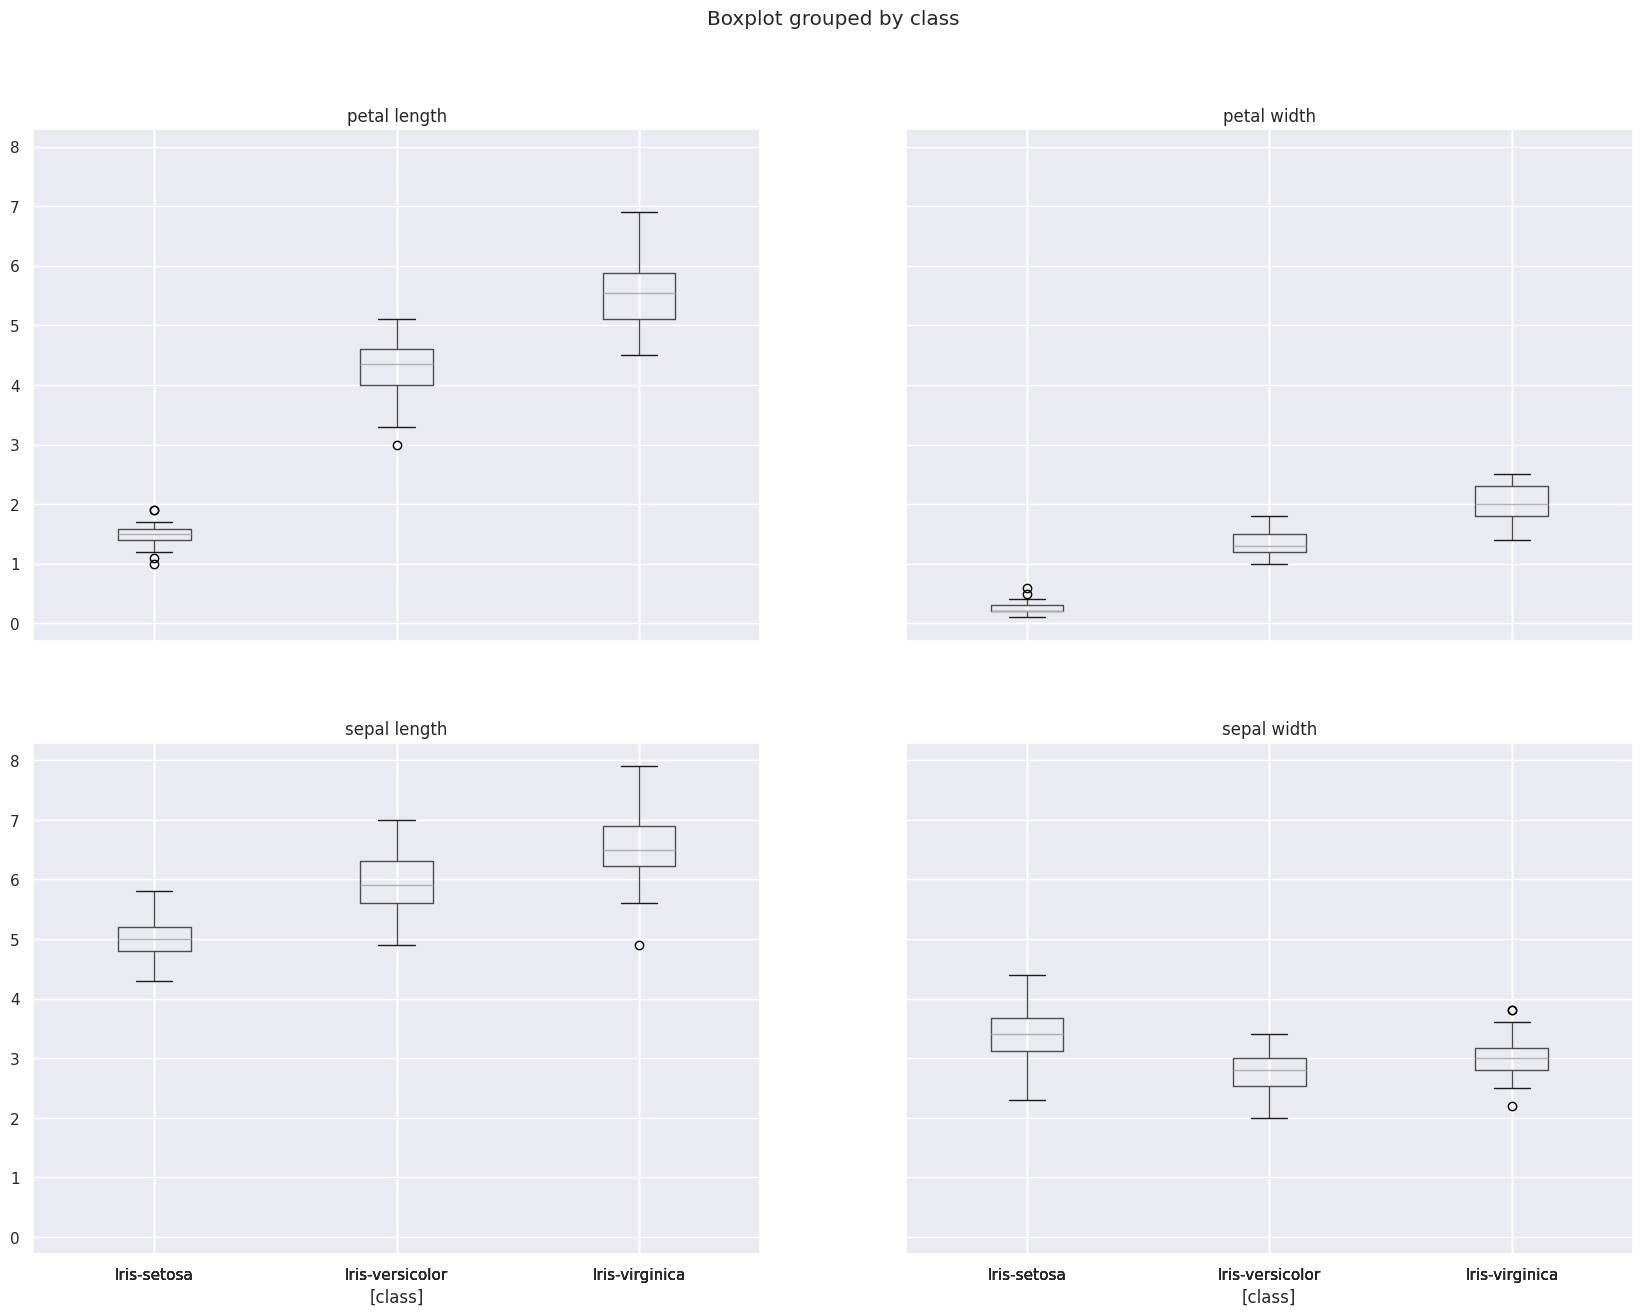

In [15]:
df.boxplot(by='class', figsize=(20,15));

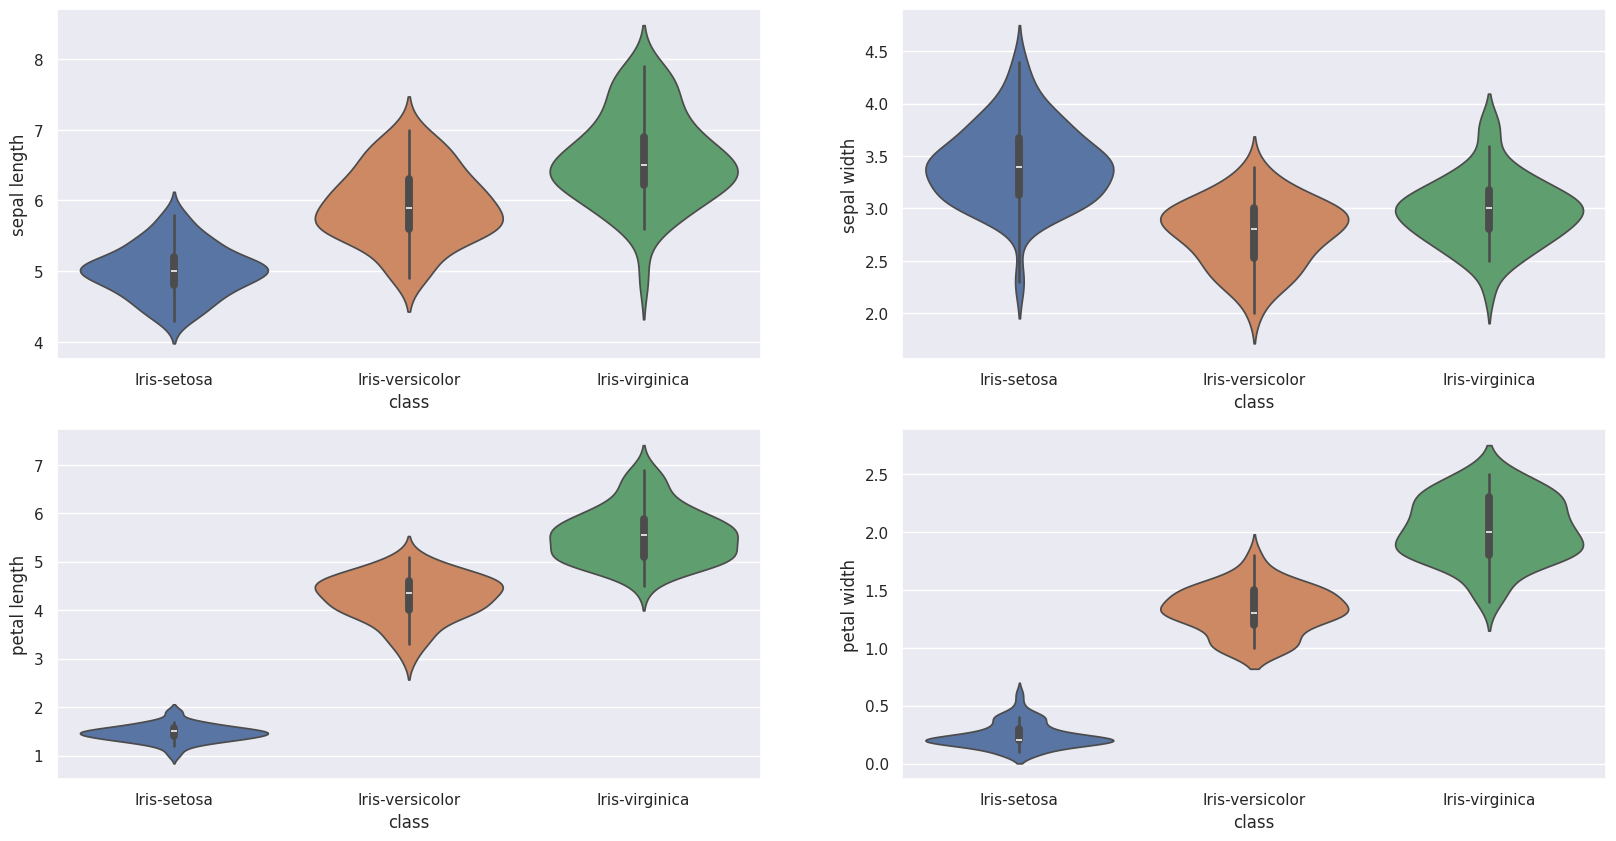

In [16]:
plt.figure(figsize=(20,10));

# subplot su matrice 2x2

plt.subplot(2,2,1)
sns.violinplot(x='class', y='sepal length', data=df,hue="class")
plt.subplot(2,2,2)
sns.violinplot(x='class', y='sepal width', data=df,hue="class")
plt.subplot(2,2,3)
sns.violinplot(x='class', y='petal length', data=df,hue="class")
plt.subplot(2,2,4)
sns.violinplot(x='class', y='petal width', data=df,hue="class");

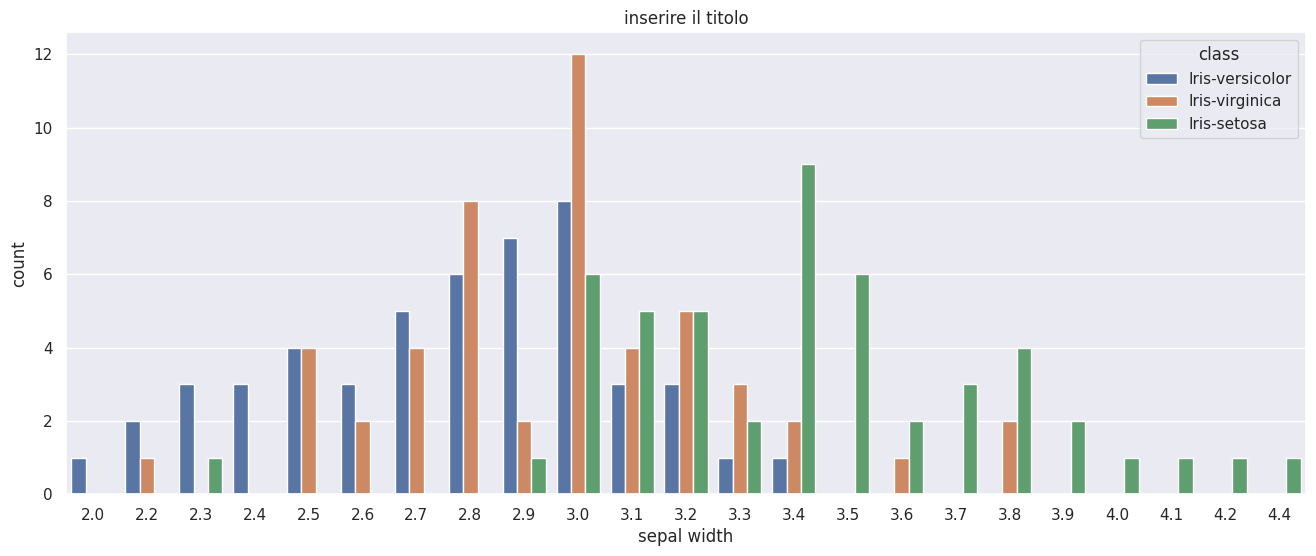

In [17]:
plt.figure(figsize=(16, 6))
plt.title('inserire il titolo')
plt.legend('class')
sns.countplot(x='sepal width',data=df,hue='class');

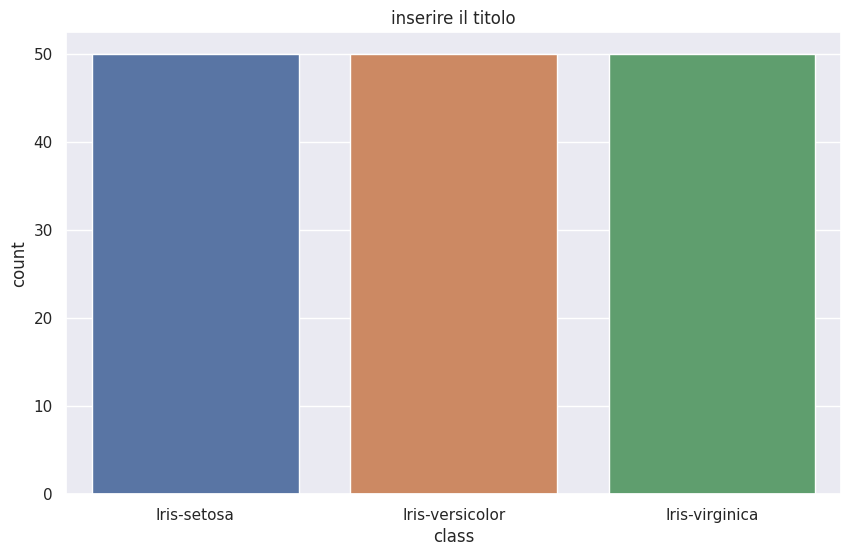

In [18]:
plt.figure(figsize=(10, 6))
plt.title('inserire il titolo')
sns.countplot(x='class', hue="class", data=df);

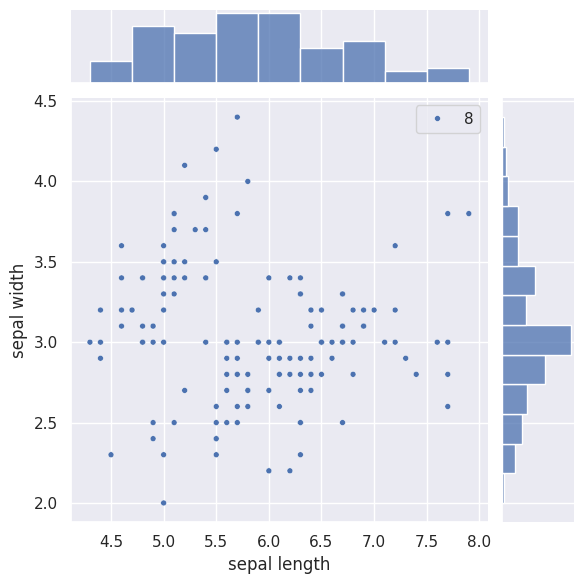

In [19]:
sns.jointplot(x="sepal length", y="sepal width", data=df, size=8);

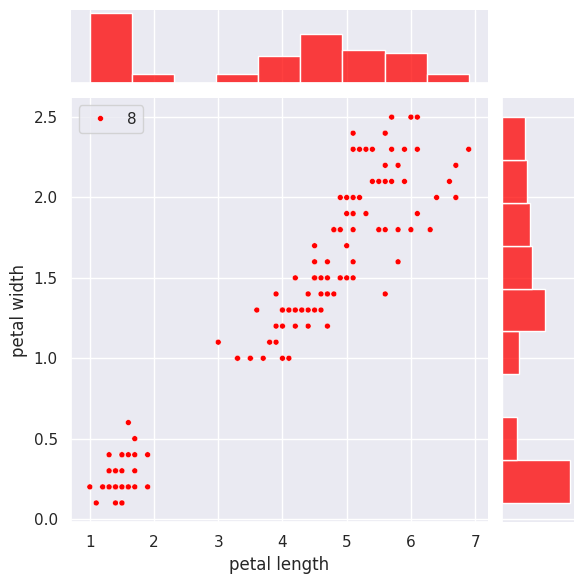

In [20]:
sns.jointplot(x="petal length", y="petal width", data=df, size=8, color='red');

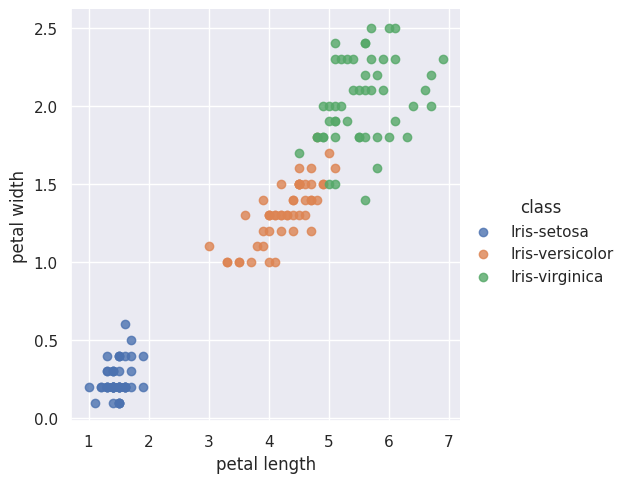

In [21]:
sns.lmplot(x="petal length", y="petal width",hue='class', data=df, fit_reg=False);

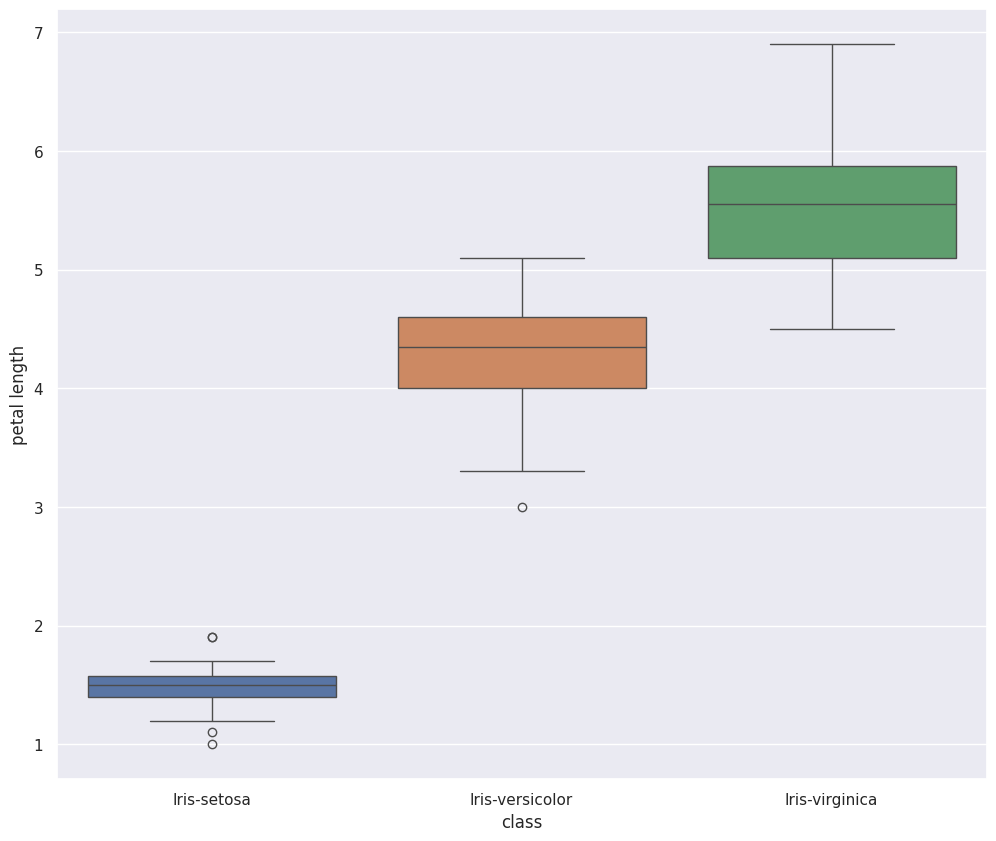

In [22]:
plt.figure(figsize=(12,10))
sns.boxplot(x="class", y="petal length", data=df,hue="class");

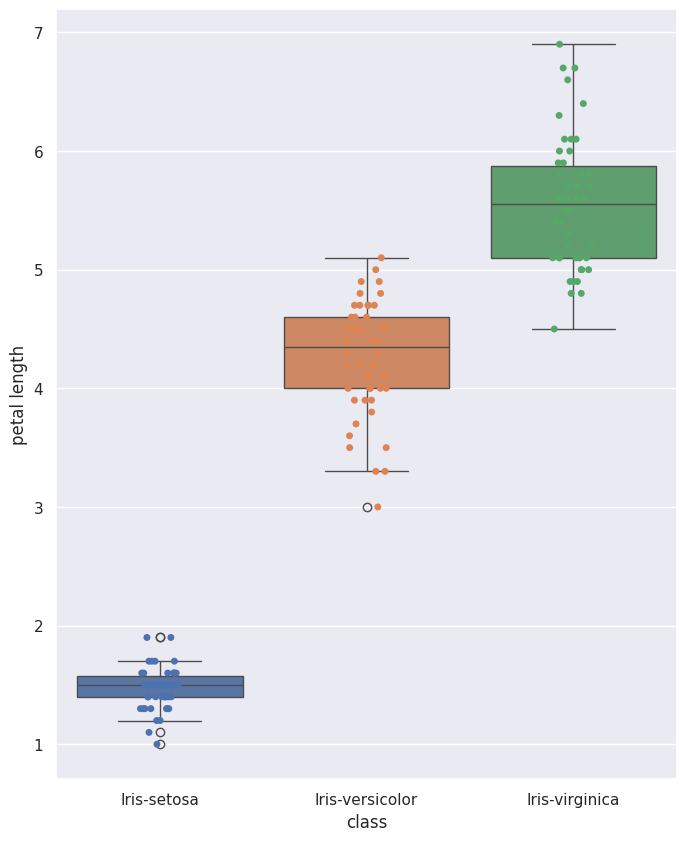

In [23]:
plt.figure(figsize=(8,10));

sns.boxplot(x="class", y="petal length", data=df,hue="class");
sns.stripplot(x="class", y="petal length", data=df,hue="class");

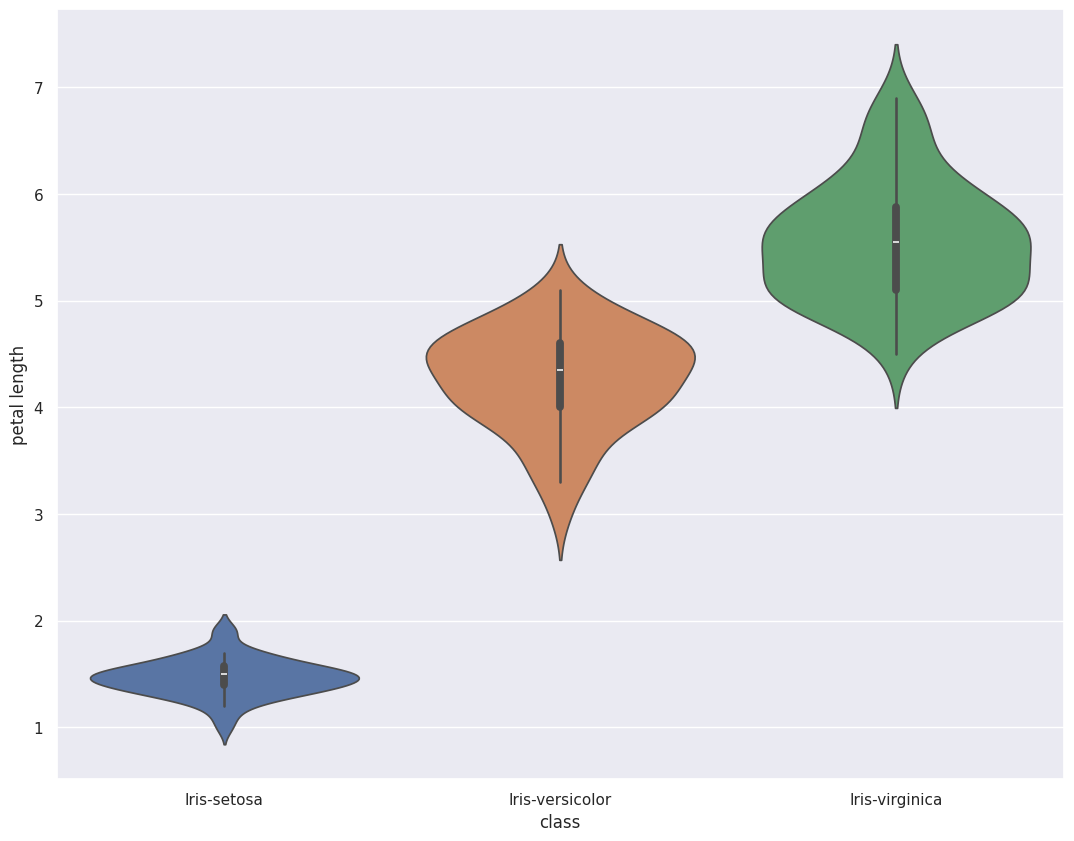

In [24]:
plt.figure(figsize=(13,10));

sns.violinplot(x="class", y="petal length", data=df,hue="class");

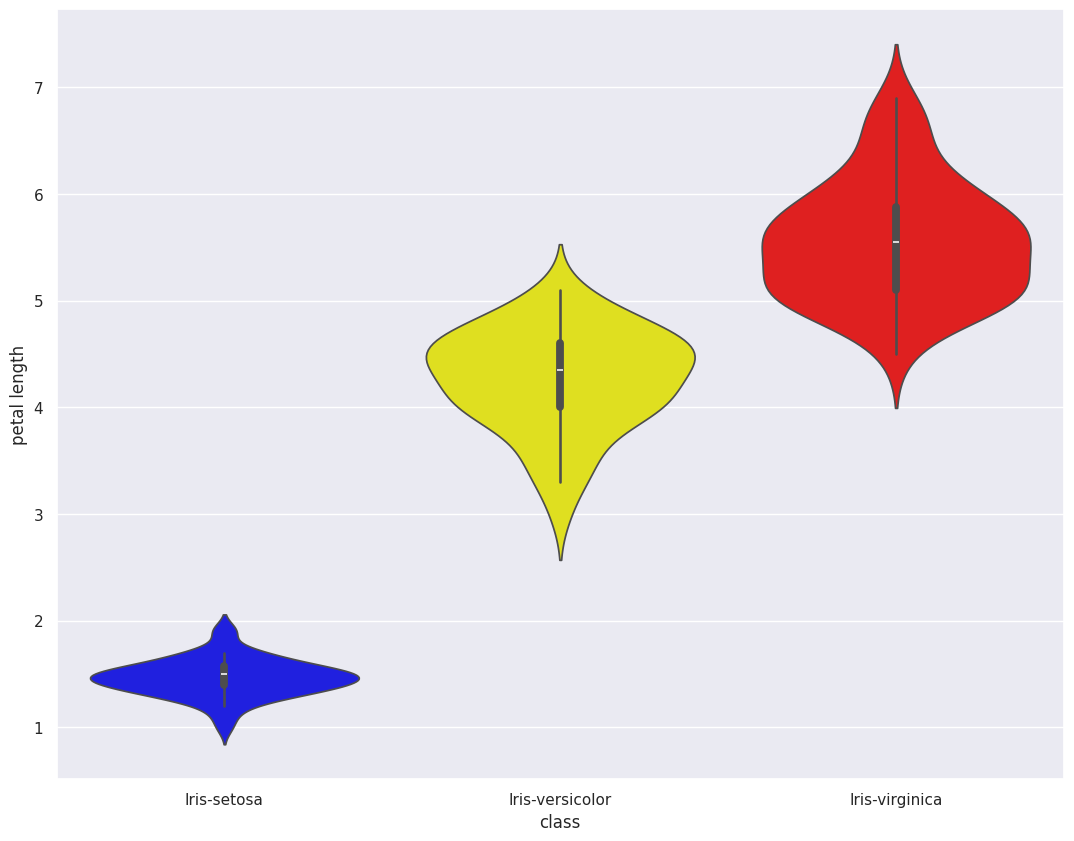

In [25]:
#palette
plt.figure(figsize=(13,10));

sns.violinplot(x="class", y="petal length",  palette={"blue","red","yellow"}, data=df,hue="class");

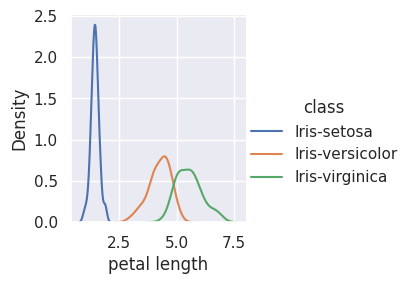

In [26]:
sns.FacetGrid(df, hue="class") \
   .map(sns.kdeplot, "petal length") \
   .add_legend();

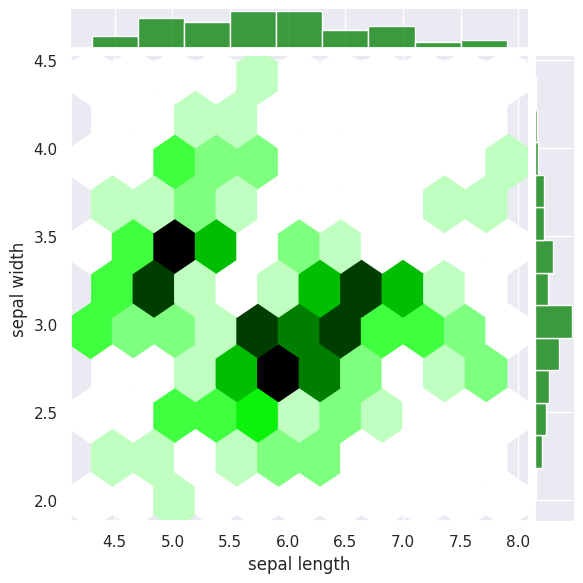

In [27]:
sns.jointplot(x="sepal length", y="sepal width", data=df,ratio=10, kind='hex',color='green')

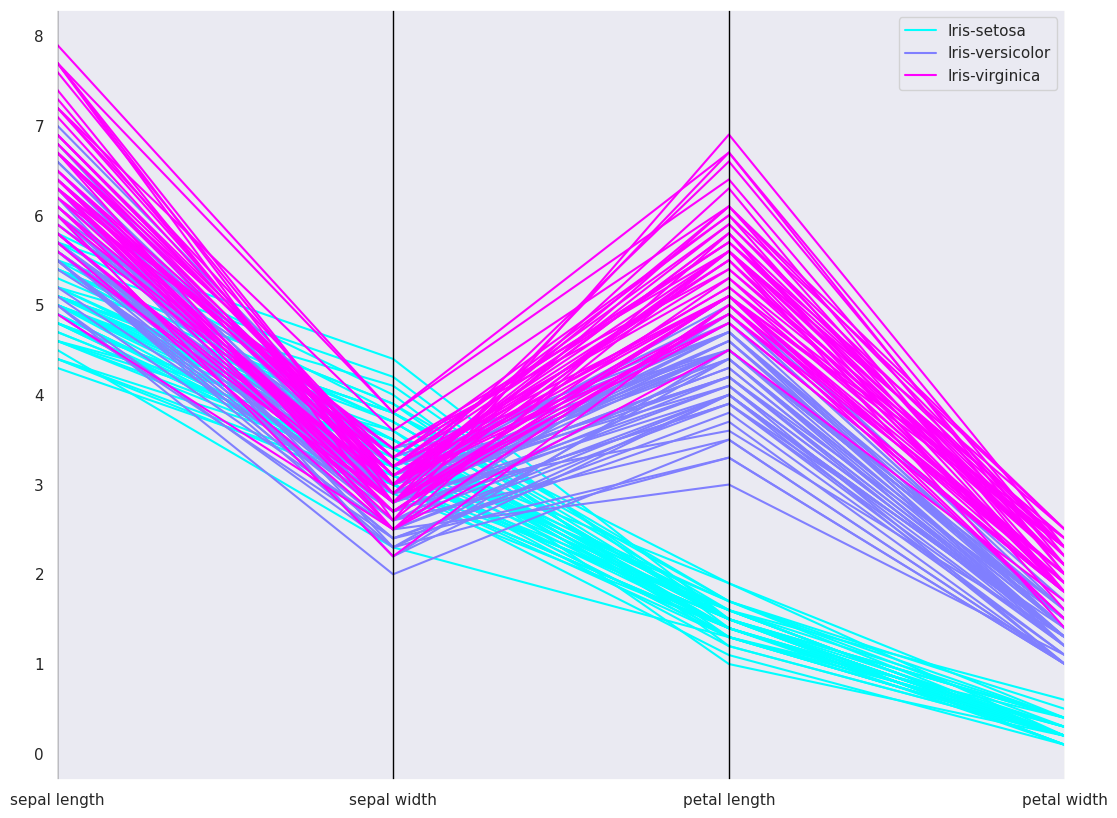

In [28]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(13,10));
parallel_coordinates(df, "class",colormap='cool');

In [29]:
import plotly.express as px
xx = px.data.iris()
fig = px.parallel_coordinates(xx, color="species_id", labels={"species_id": "Species",
                "sepal_width": "Sepal Width", "sepal_length": "Sepal Length",
                "petal_width": "Petal Width", "petal_length": "Petal Length", },
                             color_continuous_scale=px.colors.diverging.Tealrose,
                             color_continuous_midpoint=2)
fig.show()

## Q-Q Plot
Il Q-Q plot (Quantile-Quantile plot) è uno strumento grafico utilizzato per valutare se un insieme di dati segue una particolare distribuzione di probabilità, tipicamente la distribuzione normale.

Principali interpretazioni:

- Punti allineati sulla retta → i dati seguono la distribuzione
- Deviazioni agli estremi → code più pesanti o leggere
- Forma a S → asimmetria nella distribuzione
- Curve o altri pattern → i dati non seguono la distribuzione ipotizzata

È uno strumento molto utile nell'analisi esplorativa dei dati e nella verifica delle assunzioni di normalità per molti test statistici.

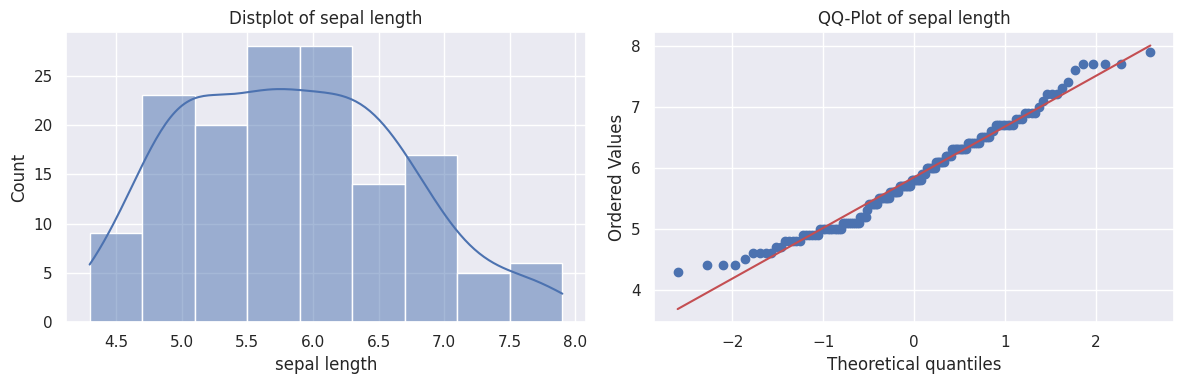

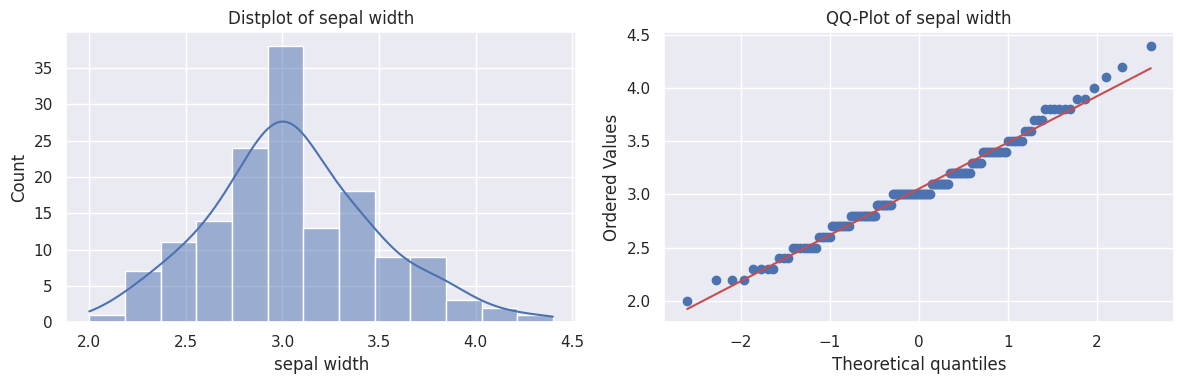

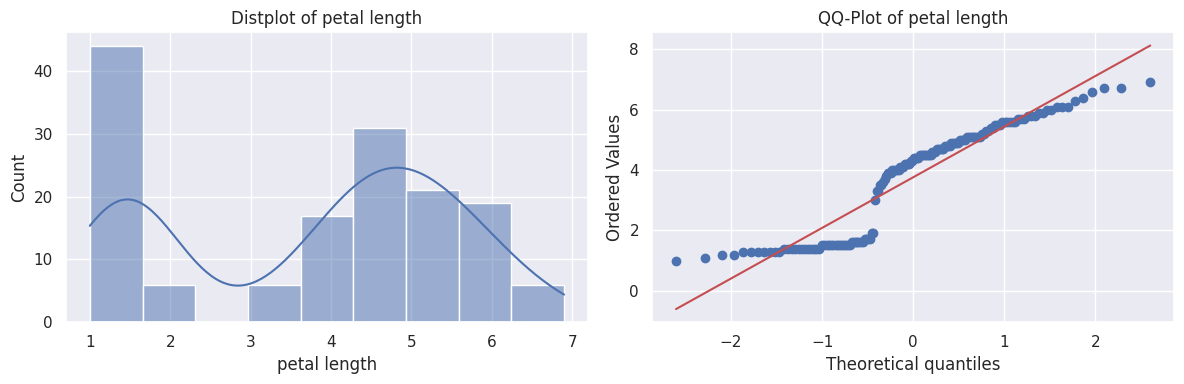

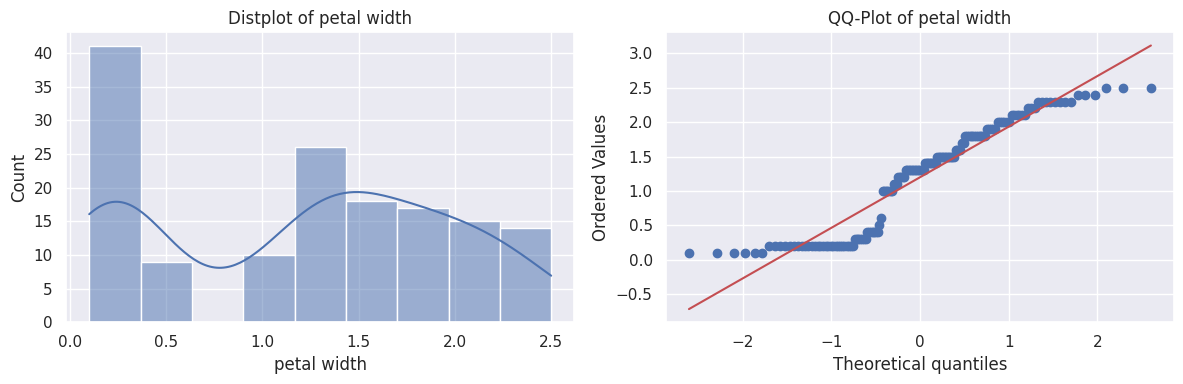

In [30]:
from scipy import stats

# Plot per ogni variabile
for column in df.iloc[:,0:-1].columns:
    plt.figure(figsize=(12, 4))

    # Histplot
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)

    plt.title(f'Distplot of {column}')

    # QQ-plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[column], dist="norm", plot=plt)
    plt.title(f'QQ-Plot of {column}')

    plt.tight_layout()
    plt.show()

## Noi utilizziamo il dataframe importato da UCI manualmente, ma abbiamo appena vrrificato chè è lo stesso

In [31]:

dataset_path='https://frenzy86.s3.eu-west-2.amazonaws.com/fav/iris.data'

df = pd.read_csv(dataset_path, header=None)
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']

df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [33]:
# store feature matrix in "x"
target = 'class'
X = df.drop(columns=[target])
# store response vector in "y"
y = df[target]

In [34]:
X.shape

(150, 4)

In [35]:
y.shape

(150,)

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
from IPython.display import Image
Image(url='https://frenzy86.s3.eu-west-2.amazonaws.com/fav/iris_8.png',width=900,height=300)

In [38]:
#Split the data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=667,
                                                    )
#print(y_test)

In [39]:
from sklearn.linear_model import LogisticRegression

#Train the model with Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train) #Training the model

LogisticRegression()

In [40]:
model.intercept_

array([ 10.19771567,   2.21242159, -12.41013726])

In [41]:
model.coef_

array([[-0.48310173,  0.70522029, -2.31495422, -0.92504766],
       [ 0.38469655, -0.22605342, -0.17392612, -0.68031424],
       [ 0.09840517, -0.47916687,  2.48888034,  1.6053619 ]])

In [42]:
# [b1_set,b2_set,b3_set,b4_set] # beta coeff setosa
# [b1_ver,b2_ver,b3_ver,b4_ver] # beta coeff versicolor
# [b1_vir,b2_vir,b3_vir,b4_vir] # beta coeff virginica

In [43]:
X_test.iloc[0]

,116
sepal length,6.5
sepal width,3.0
petal length,5.5
petal width,1.8


In [44]:
## How classification work
## X_test.iloc[0]
X1 = 6.5 # sepal length
X2 = 3.0 # sepal width
X3 = 5.5 # petal length
X4 = 1.8 # petal width

# y1=(b0_set+b1_set*X1+b2_set*X2+b3_set*X3+b4_set*X4) # Linear reg setosa
# y2=(b0_ver+b1_ver*X1+b2_ver*X2+b3_ver*X3+b4_ver*X4) # Linear reg versicolor
# y3=(b0_vir+b1_vir*X1+b2_vir*X2+b3_vir*X3+b4_vir*X4) # Linear reg virginica

y1=(10.36122821-0.47684664*X1 + 0.76508588*X2 -2.3968327*X3 -0.96721658*X4)
y2=(2.10475101+0.41151869*X1 -0.18774797*X2 -0.16175093*X3 -0.84080686*X4)
y3=(-12.46597922+0.06532795*X1 -0.57733791*X2 +2.55858363*X3 +1.80802344*X4)

p1 = 1/(1+np.exp(-y1)) #prop setosa
p2 = 1/(1+np.exp(-y2)) #prop versicolor
p3 = 1/(1+np.exp(-y3)) #prop virginica

prob = np.array([p1,p2,p3])
prob

array([0.00464834, 0.85975977, 0.97216661])

In [45]:
def softmax(x):
    """Applying softmax to the array x """
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=0)

prob_normalized = softmax(prob)
prob_normalized

array([0.16713905, 0.39305027, 0.43981068])

Where p1​, p2​, and p3​ are the probabilities for each class calculated using the logistic function.

The probabilities are calculated using the sigmoid function (the logistic function) to map the output x values to a range between 0 and 1:

$$p = \frac{1}{1 + e^{-x}}$$
However, the probabilities you've computed might not sum up to 1 due to how you've calculated and normalized them. The probabilities of each class for a given observation should sum up to 1 after the application of the softmax function.

To ensure the probabilities are correctly normalized, you should apply the softmax function to the output scores x for each class:

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{N} e^{x_j}}$$
where N is the total number of classes.

The softmax function will ensure that the probabilities sum up to 1 across all classes for a given observation. This normalization is often used in multi-class classification problems

<img src="https://frenzy86.s3.eu-west-2.amazonaws.com/python/logisticreg.png" width="800">

In [46]:
model.predict_proba(X_test)

array([[1.51773941e-04, 1.79897136e-01, 8.19951090e-01],
       [9.78689381e-01, 2.13105366e-02, 8.26879154e-08],
       [5.44588329e-03, 8.55838067e-01, 1.38716050e-01],
       [4.86624637e-02, 9.36885495e-01, 1.44520416e-02],
       [1.78620334e-01, 8.18240625e-01, 3.13904077e-03],
       [8.69902904e-03, 8.57033529e-01, 1.34267442e-01],
       [4.06246461e-05, 1.60002352e-01, 8.39957023e-01],
       [2.58007068e-04, 1.89223231e-01, 8.10518762e-01],
       [2.33818742e-02, 9.18158338e-01, 5.84597874e-02],
       [1.33348138e-03, 4.86261730e-01, 5.12404789e-01],
       [9.73189051e-01, 2.68108748e-02, 7.40482568e-08],
       [1.25717460e-02, 6.79161124e-01, 3.08267130e-01],
       [3.97606989e-02, 9.42265735e-01, 1.79735659e-02],
       [9.46306827e-01, 5.36925354e-02, 6.37726095e-07],
       [1.31570652e-05, 6.93156037e-02, 9.30671239e-01],
       [1.47741054e-04, 8.48486500e-02, 9.15003609e-01],
       [9.83518357e-01, 1.64815746e-02, 6.88066646e-08],
       [9.90696125e-01, 9.30386

In [47]:
import numpy as np

a = np.array([[10, 11, 12],
              [15, 12, 14]])

np.argmax(a, axis=1) # ci restituisce l'array degli indici di colonna dove il valore è max

array([2, 0])

In [48]:
# indice 2: "virginica"
# indice 1: "versicolor"
# indice 0: "setosa"

max_prob = np.array([np.argmax(element) for element in model.predict_proba(X_test)])
max_prob

array([2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 0, 1, 1, 0, 2, 2, 0, 0, 0, 2, 1, 1,
       0, 0, 2, 2, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 2, 0, 0, 2, 1, 2, 2,
       2])

Il metrodo predict di LogisitiRegression(), va ad associare per ogni indice di colonna di probabilitò, la corrispondente classe:
- indice 2: "virginica"
- indice 1: "versicolor"
- indice 0: "setosa"


In [49]:
#Test the model
y_pred  = model.predict(X_test)
print(y_pred )# printing predictions

['Iris-virginica' 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica']


In [50]:
confronto = pd.DataFrame(data = [y_pred,y_test])
confronto = confronto.T
confronto.columns = ['predetti', 'reali_test']
confronto

,predetti,reali_test
0,Iris-virginica,Iris-virginica
1,Iris-setosa,Iris-setosa
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-versicolor,Iris-versicolor
5,Iris-versicolor,Iris-versicolor
6,Iris-virginica,Iris-virginica
7,Iris-virginica,Iris-virginica
8,Iris-versicolor,Iris-versicolor
9,Iris-virginica,Iris-virginica


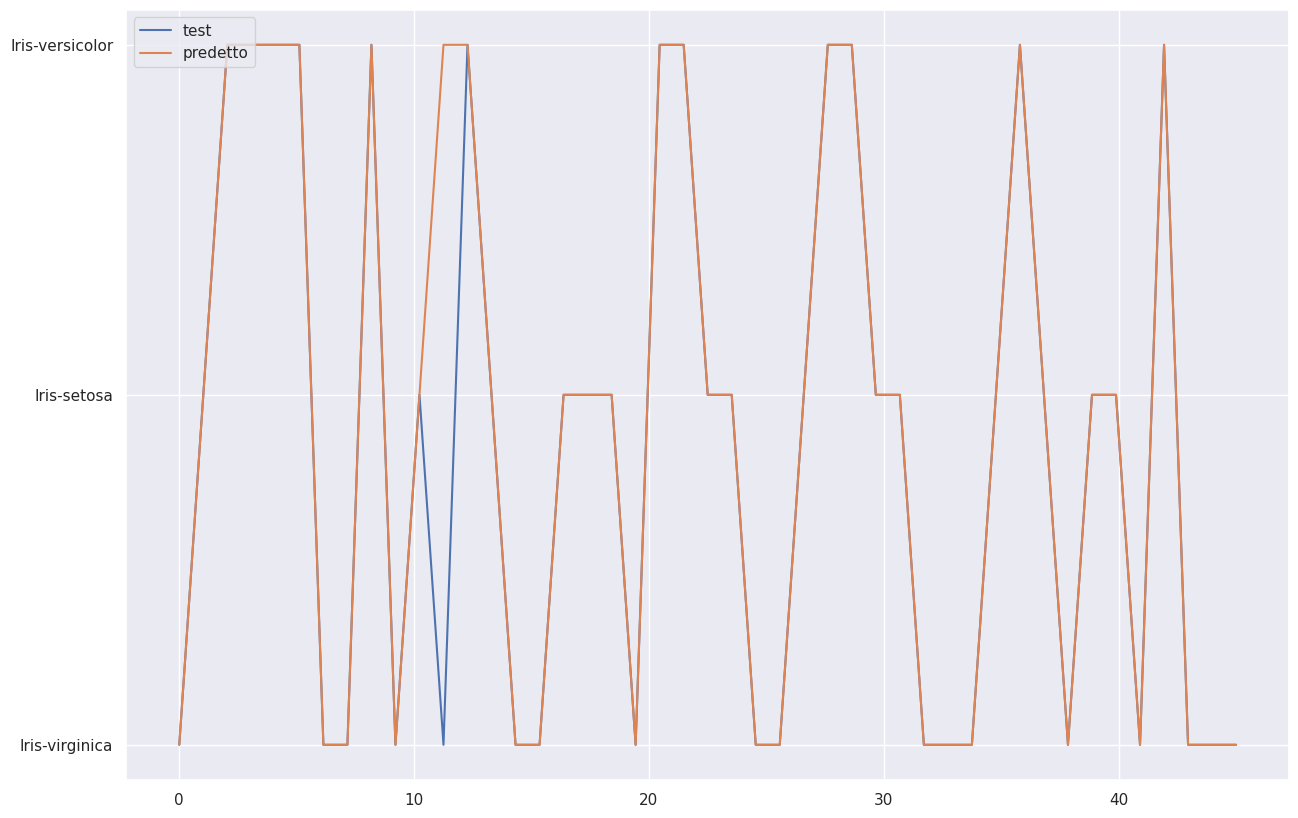

In [51]:
import numpy as np
length = y_pred.shape[0] # 30
x = np.linspace(0,length,length)


plt.figure(figsize=(15,10))
plt.plot(x, y_test, label='test')
plt.plot(x, y_pred, label='predetto')
plt.legend(loc=2);

In [52]:
model.predict([
                [2,3,5,2],
                [2,2,1,1],
               ])

array(['Iris-virginica', 'Iris-setosa'], dtype=object)

In [53]:
probs_y=model.predict_proba(X_test)
### Print results
probs_y = np.round(probs_y, 2)
res = "{:<15} | {:<15} | {:<15} | {:<15} | {:<5}".format("y_test", "y_pred", "Setosa(%)", "versicolor(%)", "virginica(%)\n")
res += "-"*65+"\n"
res += "\n".join("{:<15} | {:<15} | {:<15} | {:<15} | {:<15}".format(x, y, a, b, c) for x, y, a, b, c in zip(y_test, y_pred, probs_y[:,0], probs_y[:,1], probs_y[:,2]))
res += "\n"+"-"*65+"\n"
print(res)

y_test          | y_pred          | Setosa(%)       | versicolor(%)   | virginica(%)
-----------------------------------------------------------------
Iris-virginica  | Iris-virginica  | 0.0             | 0.18            | 0.82           
Iris-setosa     | Iris-setosa     | 0.98            | 0.02            | 0.0            
Iris-versicolor | Iris-versicolor | 0.01            | 0.86            | 0.14           
Iris-versicolor | Iris-versicolor | 0.05            | 0.94            | 0.01           
Iris-versicolor | Iris-versicolor | 0.18            | 0.82            | 0.0            
Iris-versicolor | Iris-versicolor | 0.01            | 0.86            | 0.13           
Iris-virginica  | Iris-virginica  | 0.0             | 0.16            | 0.84           
Iris-virginica  | Iris-virginica  | 0.0             | 0.19            | 0.81           
Iris-versicolor | Iris-versicolor | 0.02            | 0.92            | 0.06           
Iris-virginica  | Iris-virginica  | 0.0             | 0.4

In [54]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test,y_pred)
print(f"L'accuracy totale è: {round(acc,2)*100}%")

L'accuracy totale è: 98.0%


In [55]:
round(model.score(X_test,y_test),2)

0.98

### save model as .PKL file

In [56]:
import joblib

joblib.dump(model,"logistic_reg_iris.pkl")

['logistic_reg_iris.pkl']

### INFERENCE

In [57]:
loaded_model = joblib.load("logistic_reg_iris.pkl")
loaded_model

LogisticRegression()

In [58]:
# import ipywidgets as widgets

# def somma_quattro(a, b, c, d):
#     risultato = a + b + c + d
#     print(f"{a} + {b} + {c} + {d} = {risultato}")
#     return risultato

# ui = widgets.interactive(
#                         somma_quattro,
#                         a=widgets.FloatSlider(min=-100, max=100, step=1, value=5, description='sepal lenght'),
#                         b=widgets.FloatSlider(min=-100, max=100, step=1, value=0, description='sepal width'),
#                         c=widgets.FloatSlider(min=-100, max=100, step=1, value=0, description='petal lenght'),
#                         d=widgets.FloatSlider(min=-100, max=100, step=1, value=0, description='petal width'),
#                     )
# ui

In [70]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [76]:
import warnings
warnings.filterwarnings('ignore')

In [81]:
import ipywidgets as widgets

def predict(x1,x2,x3,x4):
    pred = loaded_model.predict([[x1,x2,x3,x4]])[0]
    print(f"con Sepal L: {x1:.1f}cm, Sepal W: {x2:.1f}cm,Petal L: {x3:.1f}cm,Petal W: {x4:.1f}cm")
    print(f" la prediction è: {pred}")
    return pred

ui = widgets.interactive(
                        predict,
                        x1=widgets.FloatSlider(min=df['sepal length'].min(), max=df['sepal length'].max(), step=0.01, value=df['sepal length'].mean(), description='sepal length'),
                        x2=widgets.FloatSlider(min=df['sepal width'].min(), max=df['sepal width'].max(), step=0.01, value=df['sepal width'].mean(), description='sepal width'),
                        x3=widgets.FloatSlider(min=df['petal length'].min(), max=df['petal length'].max(), step=0.01, value=df['petal length'].mean(), description='petal length'),
                        x4=widgets.FloatSlider(min=df['petal width'].min(), max=df['petal width'].max(), step=0.01, value=df['petal width'].mean(), description='petal width'),
                    )
ui

interactive(children=(FloatSlider(value=5.843333333333334, description='sepal length', max=7.9, min=4.3, step=…

In [60]:
X.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width'], dtype='object')

In [61]:
#sepal length', 'sepal width', 'petal length', 'petal width'

loaded_model.predict([[3,2,2,2]])[0]

'Iris-setosa'

In [62]:
def predict(x1,x2,x3,x4):
    pred = loaded_model.predict([[x1,x2,x3,x4]])[0]
    return pred

In [63]:
data = {'sepal length':[2,3,4,4],
        'sepal width':[2,3,4,4],
        'petal length':[2,3,4,4],
        'petal width':[2,3,4,4],
        }

In [64]:
df_input = pd.DataFrame(data)
df_input

,sepal length,sepal width,petal length,petal width
0,2,2,2,2
1,3,3,3,3
2,4,4,4,4
3,4,4,4,4


In [65]:
df_input['prediction'] = df_input.apply(lambda x: predict(x['sepal length'],  x['sepal width'], x['petal length'], x['petal width']), axis=1)
df_input

,sepal length,sepal width,petal length,petal width,prediction
0,2,2,2,2,Iris-setosa
1,3,3,3,3,Iris-setosa
2,4,4,4,4,Iris-virginica
3,4,4,4,4,Iris-virginica
